## Sprint 2 -- EDA and modelling 

### Section 1 : Data Understanding 
In this section, we explore the basic structure of the dataset — including its shape, data types, missing values, and the distribution of our target variable.



In [1]:
import pandas as pd
import numpy as np 

df = pd.read_csv("RainInAus.csv")

df.shape[0]

145460

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


The dataset contains 16 numerical features and 7 object (categorical) columns. What immediately stands out is that several columns have significantly fewer non-null entries — Sunshine with only 75,625 and Evaporation with 82,670 out of 145,460 rows. These two columns are already showing red flags that we'll need to address before modeling.



In [3]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


`Rainfall` has a mean of just 2.36mm but a max of 371mm — a classic sign of extreme outliers and heavy right skew. Similarly, WindGustSpeed reaches 135 km/h, suggesting some very stormy days in the dataset. 

On the other hand, temperature and pressure features look well-behaved with reasonable ranges — good news for our models.

### Missing values percentage

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage (%)', ascending=False)
missing_df

,Missing Count,Percentage (%)
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


 `Sunshine` and `Evaporation` are missing nearly 48% and 43% of their values respectively — too much to reliably impute. Cloud9am and Cloud3pm follow closely at ~40%. 
 
 These columns carry too much uncertainty to be useful, so we'll drop them during preprocessing. The remaining features have manageable missing rates under 10%, which we can safely impute.

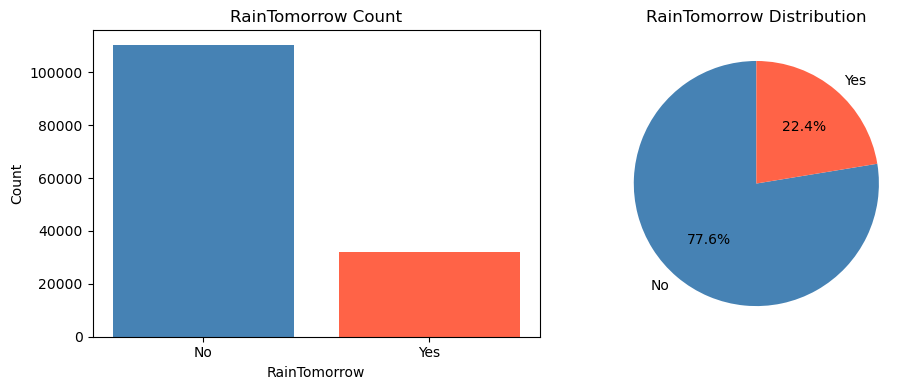

RainTomorrow
No     77.58
Yes    22.42
Name: proportion, dtype: float64


In [6]:
import matplotlib.pyplot as plt

target_counts = df['RainTomorrow'].value_counts()
target_pct = df['RainTomorrow'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(target_counts.index, target_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('RainTomorrow Count')
axes[0].set_xlabel('RainTomorrow')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(target_pct, labels=target_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('RainTomorrow Distribution')

plt.tight_layout()
plt.show()

print(target_pct.round(2))

 The target variable tells a clear story — on roughly 3 out of 4 days, it doesn't rain in Australia. This 78/22 split means we're dealing with a class imbalance problem. If we're not careful, a naive model could simply predict "No Rain" every day and still achieve 78% accuracy — without ever correctly predicting a single rainy day. This is why we'll use F1-score and ROC-AUC as our primary evaluation metrics, not just accuracy.

## EDA 

We visualize the distribution of features and explore patterns related to rainfall across different locations, seasons and weather conditions 

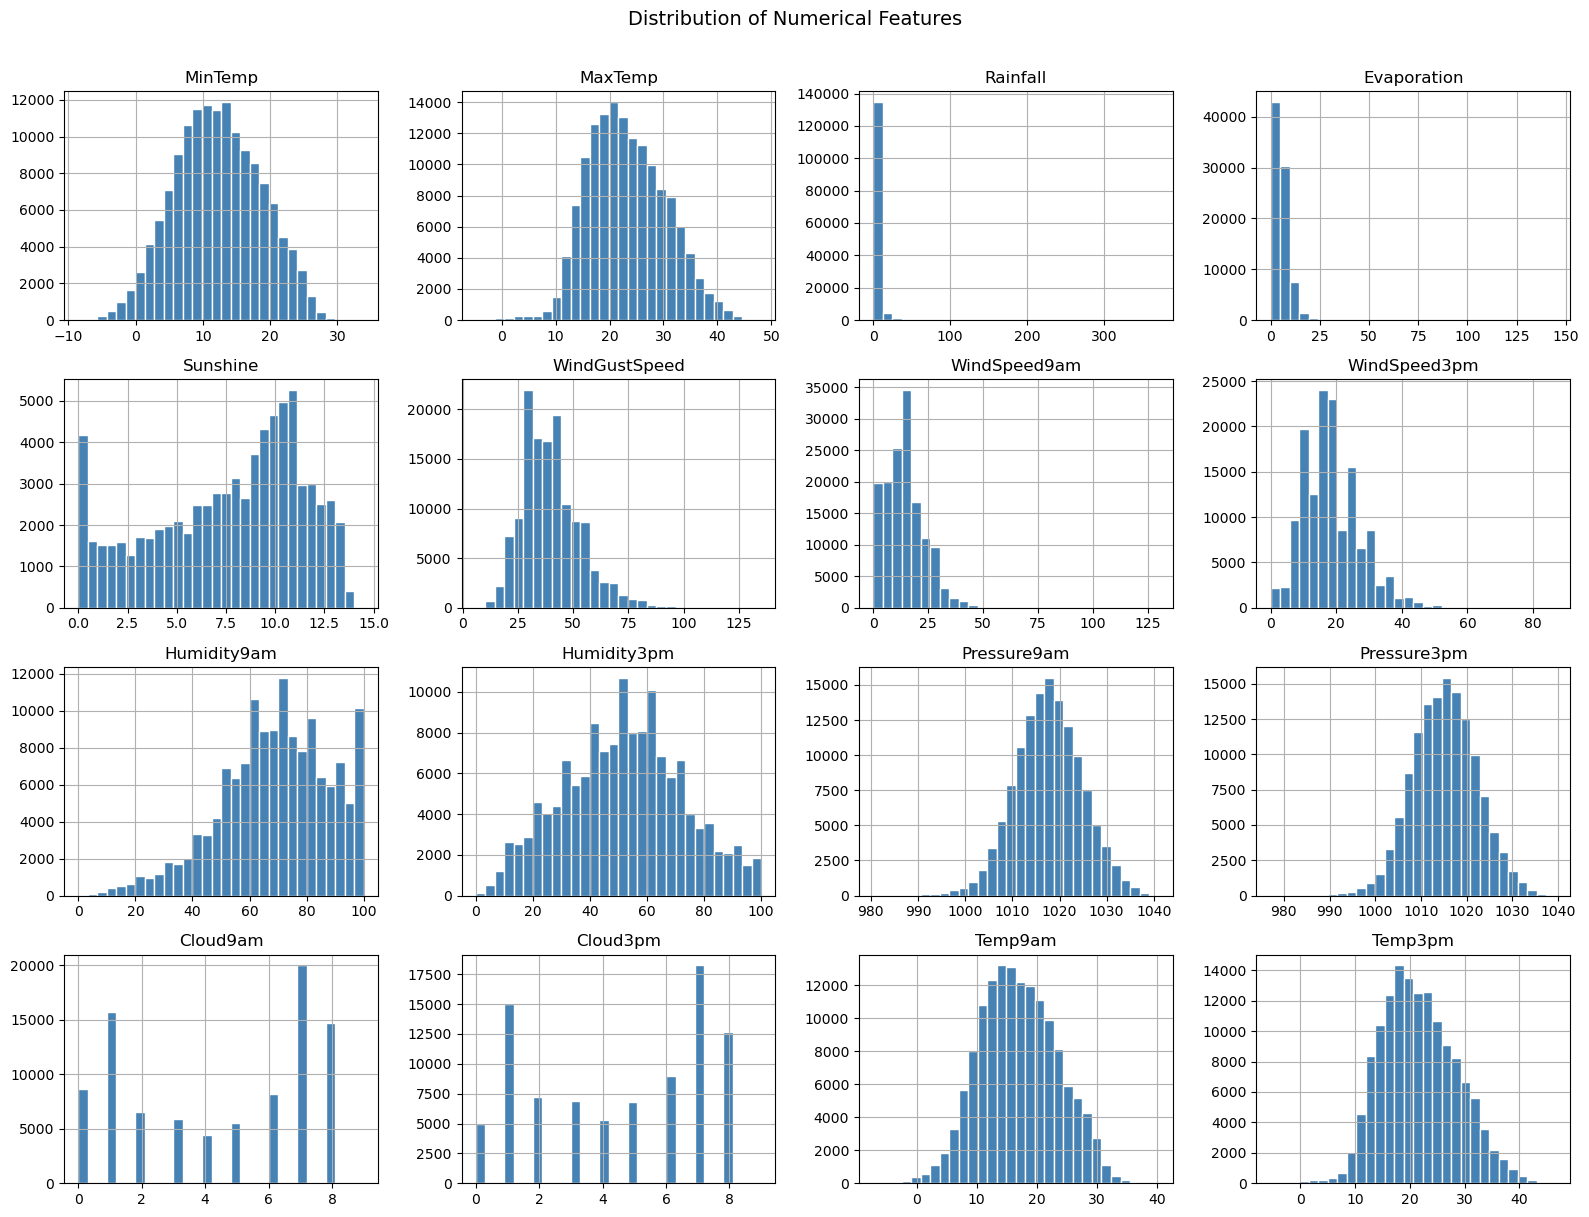

In [7]:
num_cols = df.select_dtypes(include='float64').columns.tolist()

df[num_cols].hist(figsize=(16, 12), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Right skewed data :
- `Rainfall` and `Evaporation` : most days have little to no rainfall, with some outliers 

Bimodal : 
- `Cloud9am` and `Cloud3pm `  : maybe days are mostly clear or mostly overcast 

Normal distribution :
- `temperature` and `pressure`

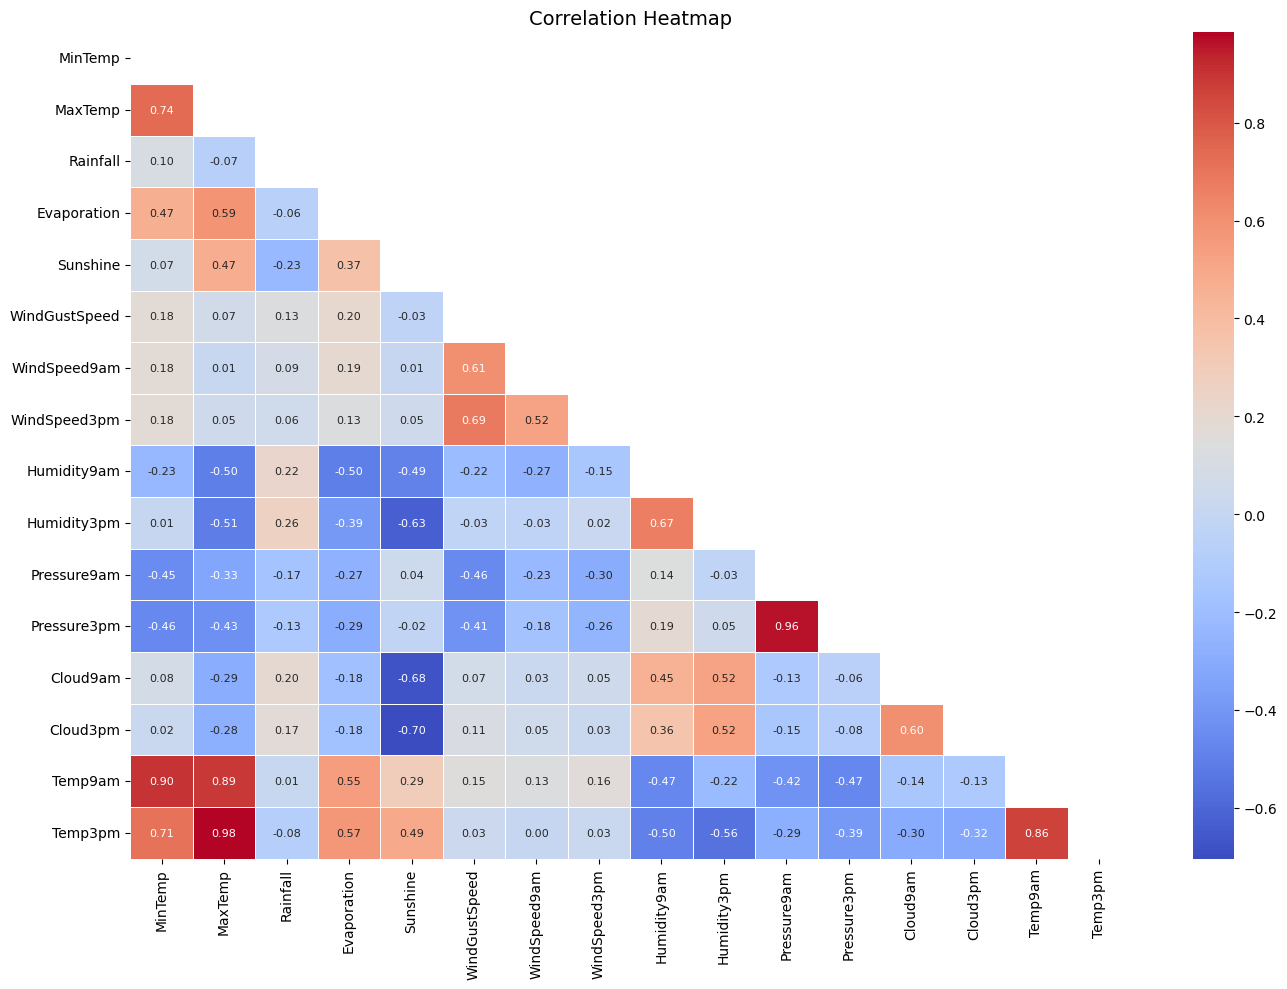

In [9]:
import seaborn as sns 


plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

The heatmap reveals some strong relationships. 
- `Pressure9am` and `Pressure3pm` are correlated at 0.96 — almost perfectly redundant, so we'll keep only one. 

- `Temp9am` and `Temp3pm` show a similar story at 0.86. 

- `Humidity3pm` shows a notable negative correlation with `Sunshine` (-0.63), hinting that humid afternoons tend to be cloudier. 


These patterns will directly influence which features matter most when predicting rain.



## Rainfall by location 

C:\Users\erteo\AppData\Local\Temp\ipykernel_5788\4216655301.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rain_by_location, x='Location', y='RainDays (%)', palette='Blues_r')


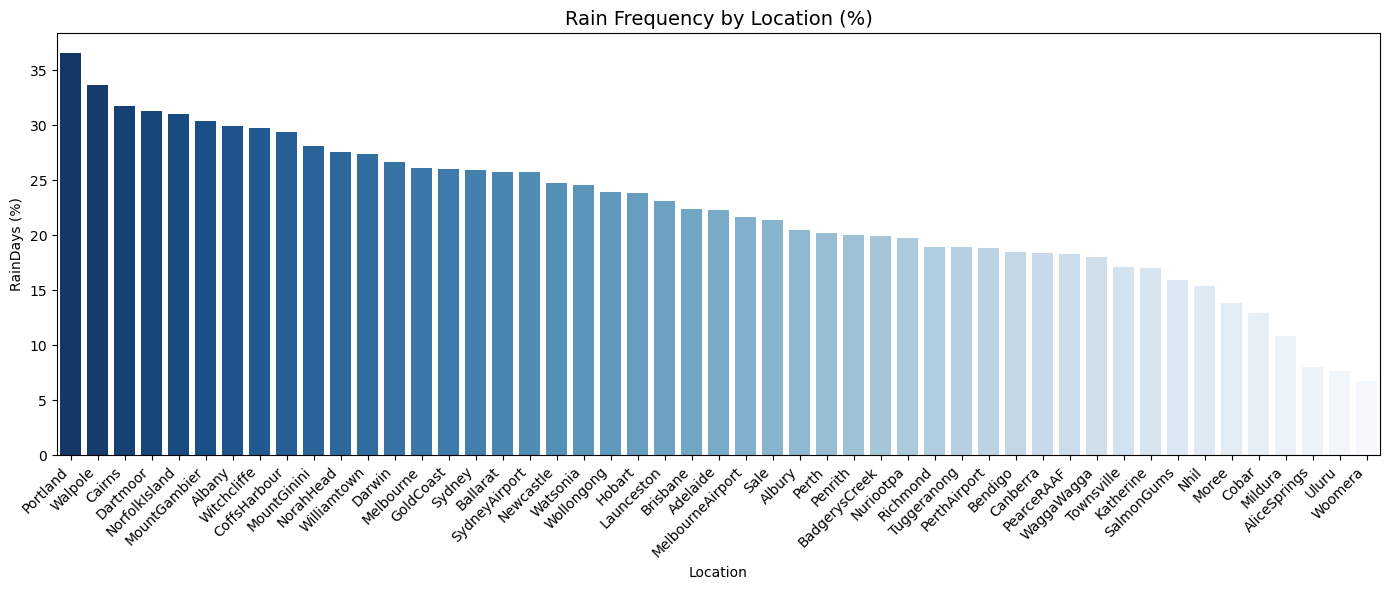

In [10]:
rain_by_location = df.groupby('Location')['RainTomorrow'].apply(
    lambda x: (x == 'Yes').sum() / x.count() * 100
).sort_values(ascending=False).reset_index()
rain_by_location.columns = ['Location', 'RainDays (%)']

plt.figure(figsize=(14, 6))
sns.barplot(data=rain_by_location, x='Location', y='RainDays (%)', palette='Blues_r')
plt.title('Rain Frequency by Location (%)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\erteo\AppData\Local\Temp\ipykernel_5788\3501930192.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RainTomorrow', y=col, palette={'No': 'steelblue', 'Yes': 'tomato'}, ax=axes[i])
C:\Users\erteo\AppData\Local\Temp\ipykernel_5788\3501930192.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RainTomorrow', y=col, palette={'No': 'steelblue', 'Yes': 'tomato'}, ax=axes[i])
C:\Users\erteo\AppData\Local\Temp\ipykernel_5788\3501930192.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RainTomorrow', 

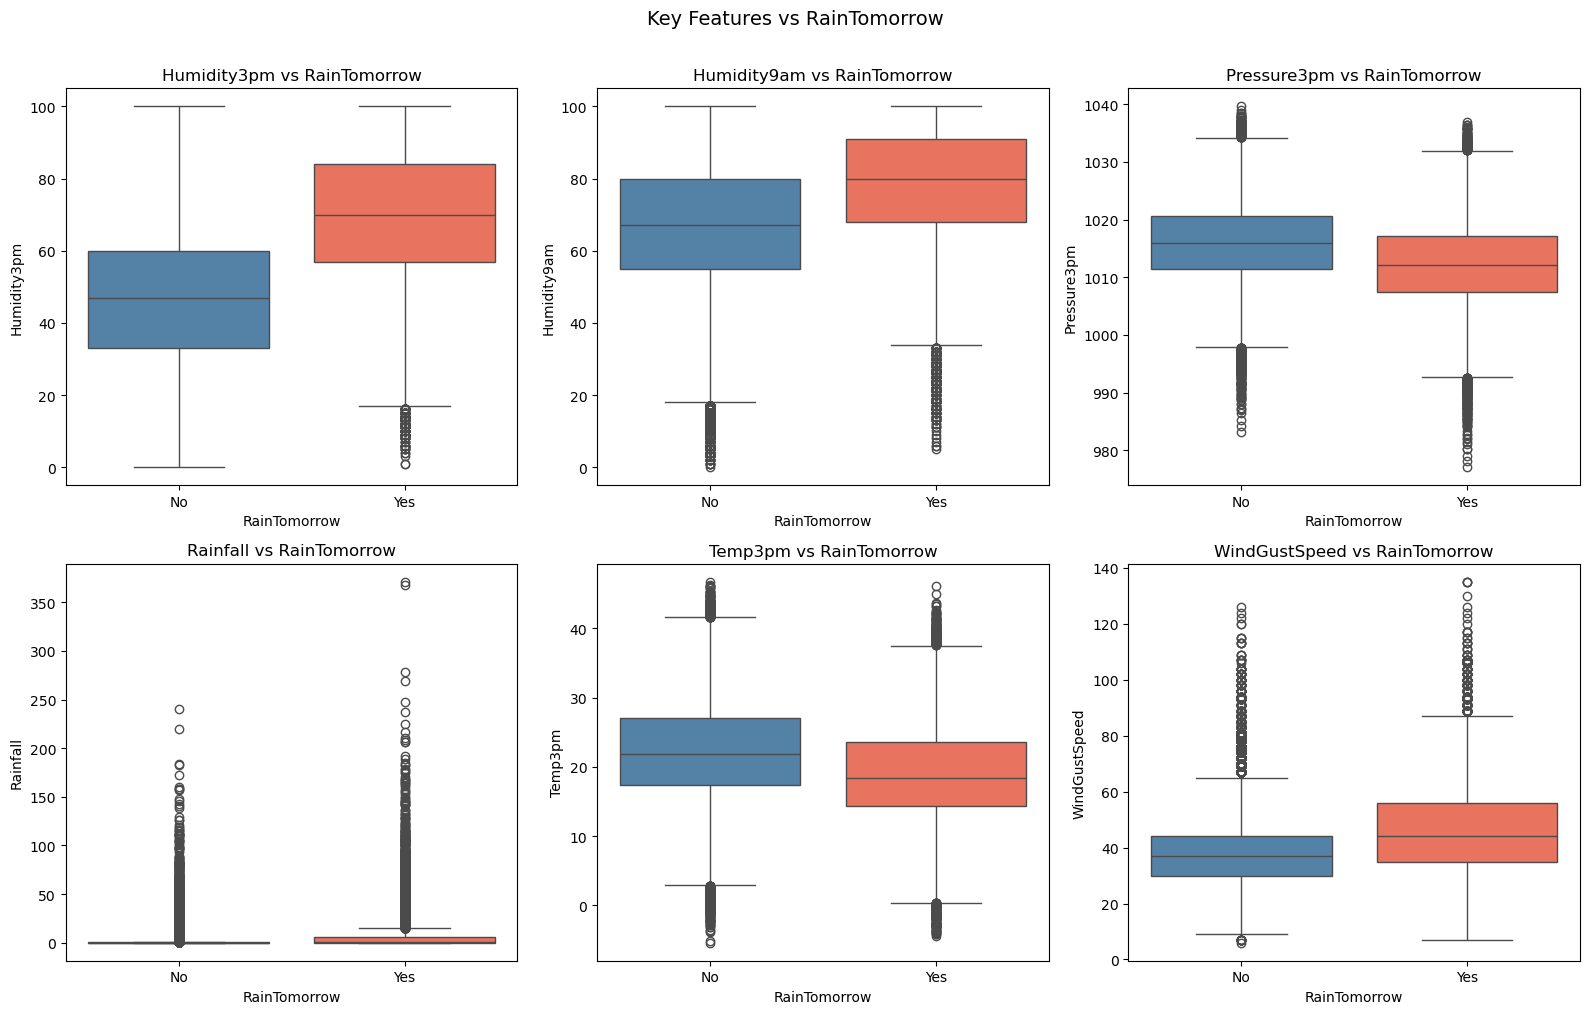

In [11]:
key_features = ['Humidity3pm', 'Humidity9am', 'Pressure3pm', 'Rainfall', 'Temp3pm', 'WindGustSpeed']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='RainTomorrow', y=col, palette={'No': 'steelblue', 'Yes': 'tomato'}, ax=axes[i])
    axes[i].set_title(f'{col} vs RainTomorrow')

plt.suptitle('Key Features vs RainTomorrow', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

When it rains tomorrow:

- `Humidity3pm` is noticeably higher — the air is already saturated in the afternoon.
- `Pressure3pm` is lower — falling pressure is a classic meteorological sign of incoming weather systems.
- `WindGustSpeed` is stronger — storms bring wind.
- `Temp3pm` tends to be lower on rainy days — clouds block sunlight and keep temperatures down.

These patterns confirm that our features carry real predictive signal. The models should have something meaningful to learn from.

## Data Preprocessing 
### Drop High-Missing & Redundant Columns


In [12]:
# Drop columns with >40% missing & highly correlated duplicates
cols_to_drop = ['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm', 'Pressure9am', 'Temp9am']
df_clean = df.drop(columns=cols_to_drop)

# Drop rows where target is missing
df_clean = df_clean.dropna(subset=['RainTomorrow'])

print(f"Shape after dropping: {df_clean.shape}")

Shape after dropping: (142193, 17)


In [13]:
# Impute numerical with median
num_cols = df_clean.select_dtypes(include='float64').columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# Impute categorical with mode
cat_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values remaining:", df_clean.isnull().sum().sum())

Missing values remaining: 0


## Encode Categorical Features 

In [15]:
from sklearn.preprocessing import LabelEncoder

# Label encode binary columns
le = LabelEncoder()
df_clean['RainToday'] = le.fit_transform(df_clean['RainToday'])
df_clean['RainTomorrow'] = le.fit_transform(df_clean['RainTomorrow'])

# One-hot encode wind direction columns
df_clean = pd.get_dummies(df_clean, columns=['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Location'], drop_first=True)

# Drop Date column
df_clean = df_clean.drop(columns=['Date'])

print(f"Final shape: {df_clean.shape}")

Final shape: (142193, 105)


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['RainTomorrow'])
y = df_clean['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape}")
print(f"Test size : {X_test.shape}")
print(f"Target distribution (train):\n{y_train.value_counts(normalize=True).round(3)}")

Train size: (113754, 104)
Test size : (28439, 104)
Target distribution (train):
RainTomorrow
0    0.776
1    0.224
Name: proportion, dtype: float64


## Model Selection

I plan to use only to test with one feature first, then move on with training with more columns.

Here we will train three different classification model 

## Feature Engineering


**A. Temporal Features (from `Date`)**

- Month & Season: Extract month and season.
Justification: EV range is cyclical. Cars use extensive heating in winter (drastically dropping range) and air conditioning in summer.

- Day of Year: Represented as a cyclical continuous feature (using sine/cosine transformations).

**B. Temperature Features (from `MinTemp`, `MaxTemp`, `Temp9am`, `Temp3pm`)**

- Average Daily Temperature: (Temp9am + Temp3pm) / 2 or (MaxTemp + MinTemp) / 2.
Justification: This is the most crucial variable for EV range prediction. Optimal EV efficiency occurs around 20°C - 22°C. 

For instance, energy consumption increases by 20% when it gets hot (30°C) and spikes by up to 67% in freezing conditions (-7°C) [Two_stage_optimization]

HVAC Load Proxy: A binary or continuous feature where temperatures below 15°C indicate "Heating Needed" and over 25°C "Cooling Needed".

**C. Wind Factors (from `WindGustSpeed`, `WindSpeed9am/3pm`, `WindDir`)**

- Average Wind Speed:
Justification: Aerodynamic drag increases with the square of speed. High headwinds heavily deplete EV batteries on highways.
Wind Severity Index: A categorical bucket (e.g., Calm, Moderate, Gale) based on wind gust speed.

**D. Precipitation / Road Conditions (from `Rainfall`, `RainToday`)**

Rolling Resistance Indicator:
Justification: If `Rainfall` > 0, roads are wet. Driving through surface water drastically increases rolling resistance, demanding more torque and battery drain.


**E. Speed and Energy Trade Off**
Multi-criteria optimization handles the trade-off between speed and energy by combining them into a single mathematical formula, usually called a weighted objective function

There is a direct conflict between these two factors: driving faster reduces your total travel time, but it drastically increases energy consumption due to travel resistance and aerodynamic drag
To balance this, the algorithm assigns different weights to each goal based on what is most important for that specific trip
It then calculates the exact optimal speed for every individual segment of the route rather than assuming a constant speed

For example, in one simulation, the system found that driving at an average of 70 km/h minimized travel time, while dropping the speed down to about 25 km/h was the most energy-efficient choice

## System Architecture
This solution cannot be solved by a single machine learning model. Instead, it requires a pipeline of three interconnected systems:

### Step 1: The Weather Predictor (Machine Learning)
Goal: Predict the weather for a given route on a specific day.
Model: XGBoost Regression model or an LSTM Time Series model 
Input: Current date, time, and location.
**Output:** Predicted temperature, wind speed, and rain for that day.


### Step 2: The Energy Consumption Model (Machine Learning)
Goal: Predict how much battery (kWh) will be consumed on a specific road segment.
Model: A Random Forest Regressor or Deep Neural Network.
Input features:
- Segment distance and elevation change (from Maps)
- Expected driving speed
- Predicted Weather outputs from Step 1 (Temp, Wind, Rain).
**Output:** Predicted energy cost for that segment.

### Step 3: The Routing Algorithm (Graph Search Algorithm)
Goal: Find the best route, and detour to charging stations if needed.
Model: Modified Fuzzy A*

How it works:
1. The map is a graph of nodes (intersections) and edges (roads).
2. The algorithm tests different paths to the destination. As it travels down edges, it subtracts the EV's current battery by the predicted output of Step 2.
3. If the predicted Current Battery drops below a safe threshold (e.g., 10%), the algorithm adds a massive mathematical "penalty" to that path.
4. It is forced to instead calculate a path through a graph node known to be a Charging Station before reaching the destination.

## Step 1 : Weather prediction

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

rain_df = pd.read_csv("RainInAus.csv")

#drop rows where target are missing 
targets = ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm', 
                 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Rainfall']
df = rain_df.dropna(subset=targets).copy()

# 3. Temporal Feature Engineering (from 'Date')
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['DayOfYear'] = df['Date'].dt.dayofyear

# Define Season mapping (1: Summer, 2: Autumn, 3: Winter, 4: Spring)
df['Season'] = (df['Date'].dt.month % 12 + 3) // 3 

# Cyclical transformation for Day of Year (highly important for time-series/weather)
df['DayOfYear_sin'] = np.sin(2 * np.pi * df['DayOfYear'] / 365.25)
df['DayOfYear_cos'] = np.cos(2 * np.pi * df['DayOfYear'] / 365.25)



In [6]:
# B. Temperature Features 
df['Avg_Daily_Temp'] = (df['MaxTemp'] + df['MinTemp']) / 2
# HVAC Load Proxy: -1 (Heating), 1 (Cooling), 0 (Optimal)
def get_hvac_proxy(temp):
    if temp < 15: return -1
    elif temp > 25: return 1
    else: return 0
df['HVAC_Load_Proxy'] = df['Avg_Daily_Temp'].apply(get_hvac_proxy)

# C. Wind Factors
df['Avg_Wind_Speed'] = (df['WindSpeed9am'] + df['WindSpeed3pm']) / 2
# Wind Severity Index based on WindGustSpeed (< 30: Calm, 30-50: Mod, > 50: Gale)
def get_wind_severity(gust):
    if gust < 30: return 0      # Calm
    elif gust <= 50: return 1   # Moderate
    else: return 2                # Gale
df['Wind_Severity_Index'] = df['WindGustSpeed'].apply(get_wind_severity)

# D. Precipitation / Road Conditions
# Rolling Resistance Indicator: 1 if wet, 0 if dry
df['Rolling_Resistance_Ind'] = (df['Rainfall'] > 0).astype(int)

In [28]:
# 4. Location Encoding
# Tree-based models (like XGBoost) handle label encoded categories well
le = LabelEncoder()
df['Location_encoded'] = le.fit_transform(df['Location'])

# 5. Define Feature Matrix (X) and Target Matrix (y)
features = ['Location_encoded', 'Month', 'Season', 'DayOfYear_sin', 'DayOfYear_cos']
targets = ['MaxTemp','MinTemp','Avg_Daily_Temp','Avg_Wind_Speed','Rainfall']

X = df[features]
y = df[targets]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Set size:{X_train.shape}")
print(f"Test set size: {X_test.shape}")

print(f"Training Set size:{y_train.shape}")
print(f"Test set size: {y_test.shape}")

Training Set size:(104807, 5)
Test set size: (26202, 5)
Training Set size:(104807, 5)
Test set size: (26202, 5)


In [29]:
import time
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. Initialize the Model
xgb_core = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42
)
weather_model = MultiOutputRegressor(xgb_core)

# 2. Train 
print("Training Weather Predictor...")
time_start = time.time()             

weather_model.fit(X_train, y_train)

time_end = time.time()               
print(f" Time taken: {time_end - time_start:.2f} seconds.")

# 3. Predict on the Test Set
predictions = weather_model.predict(X_test)

# Map the predictions to a DataFrame 
preds_df = pd.DataFrame(predictions, columns=['MaxTemp','MinTemp','Avg_Daily_Temp', 'Avg_Wind_Speed', 'Rainfall'])

# 4. Evaluate the Model (Updated columns to match Feature Engineering)
print("\n--- Mean Absolute Error (MAE) ---")
print(f"Avg Max Temp Error: {mean_absolute_error(y_test['MaxTemp'], preds_df['MaxTemp']):.2f} °C")
print(f"Avg Min Temp Error: {mean_absolute_error(y_test['MinTemp'], preds_df['MinTemp']):.2f} °C")
print(f"Avg Daily Temp Error: {mean_absolute_error(y_test['Avg_Daily_Temp'], preds_df['Avg_Daily_Temp']):.2f} °C")
print(f"Avg Wind Speed Error: {mean_absolute_error(y_test['Avg_Wind_Speed'], preds_df['Avg_Wind_Speed']):.2f} km/h")
print(f"Rainfall Error:       {mean_absolute_error(y_test['Rainfall'], preds_df['Rainfall']):.2f} mm")


Training Weather Predictor...
 Time taken: 0.94 seconds.

--- Mean Absolute Error (MAE) ---
Avg Max Temp Error: 2.77 °C
Avg Min Temp Error: 2.49 °C
Avg Daily Temp Error: 2.15 °C
Avg Wind Speed Error: 4.98 km/h
Rainfall Error:       3.34 mm


sklearn custom metrics 

svm - for non linear 




In [8]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. MUST sort by Location and Date to keep the timeline perfectly intact
df_lstm = df.sort_values(by=['Location', 'Date']).copy()

# 2. Scale the features to be between 0 and 1
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# We scale our X and y separately so we can easily "inverse_transform" the predictions later
X_scaled = scaler_X.fit_transform(df_lstm[features])
y_scaled = scaler_y.fit_transform(df_lstm[targets])

# 3. Create Sliding Windows (Look back 7 days to predict the 8th day)
TIME_STEPS = 7

X_seq, y_seq = [], []
for i in range(len(X_scaled) - TIME_STEPS):
    X_seq.append(X_scaled[i : i + TIME_STEPS]) # The past 7 days of features
    y_seq.append(y_scaled[i + TIME_STEPS])     # The targets on day 8

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# 4. Split sequentially! (First 80% of time for training, last 20% for testing)
split_idx = int(len(X_seq) * 0.8)

X_train_lstm = X_seq[:split_idx]
X_test_lstm  = X_seq[split_idx:]
y_train_lstm = y_seq[:split_idx]
y_test_lstm  = y_seq[split_idx:]

print(f"LSTM Input Shape: {X_train_lstm.shape}") 
# Shape will be (Rows, 7 Time Steps, 5 Features)


LSTM Input Shape: (104801, 7, 5)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Define the Neural Network Architecture
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIME_STEPS, len(features))),
    Dropout(0.2), # Dropout prevents the model from overfitting
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(len(targets)) # Output layer predicting 3 things: Temp, Wind, Rain
])

# 2. Compile the Model
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 3. Train the Model! 
# Warning: LSTMs take significantly longer to train than XGBoost
print("Training LSTM Weather Predictor...")
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=15,
    batch_size=64,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)
print("LSTM Training Complete")


Training LSTM Weather Predictor...
Epoch 1/15


c:\Users\erteo\.conda\envs\NLP330\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1638/1638 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0085 - mae: 0.0622 - val_loss: 0.0062 - val_mae: 0.0532
Epoch 2/15
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0071 - mae: 0.0566 - val_loss: 0.0062 - val_mae: 0.0527
Epoch 3/15
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0070 - mae: 0.0561 - val_loss: 0.0063 - val_mae: 0.0535
Epoch 4/15
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0068 - mae: 0.0557 - val_loss: 0.0070 - val_mae: 0.0589
Epoch 5/15
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0067 - mae: 0.0552 - val_loss: 0.0062 - val_mae: 0.0539
Epoch 6/15
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0065 - mae: 0.0541 - val_loss: 0.0065 - val_mae: 0.0562
Epoch 7/15
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0063 - mae: 0.0534 - val_loss: 0.0065 - val_mae: 0.0555
Epoch 8/15
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0065 - mae: 0.0541 - val_loss: 0.0063 - val_mae: 0.0546
Epoch 9/15
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 12s 7

In [10]:
from sklearn.metrics import mean_absolute_error

# 1. Make predictions on the test set
lstm_predictions_scaled = lstm_model.predict(X_test_lstm)

# 2. INVERSE TRANSFORM both the truth and predictions!
lstm_predictions_real = scaler_y.inverse_transform(lstm_predictions_scaled)
y_test_real = scaler_y.inverse_transform(y_test_lstm)

# 3. Put them into DataFrames for easy calculation
preds_df = pd.DataFrame(lstm_predictions_real, columns=targets)
truth_df = pd.DataFrame(y_test_real, columns=targets)

# 4. Calculate proper human-readable Error Metrics
print("\n--- LSTM Mean Absolute Error (MAE) ---")
print(f"Avg Daily Temp Error: {mean_absolute_error(truth_df['Avg_Daily_Temp'], preds_df['Avg_Daily_Temp']):.2f} °C")
print(f"Avg Wind Speed Error: {mean_absolute_error(truth_df['Avg_Wind_Speed'], preds_df['Avg_Wind_Speed']):.2f} km/h")
print(f"Rainfall Error:       {mean_absolute_error(truth_df['Rainfall'], preds_df['Rainfall']):.2f} mm")


819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

--- LSTM Mean Absolute Error (MAE) ---
Avg Daily Temp Error: 7.16 °C
Avg Wind Speed Error: 7.91 km/h
Rainfall Error:       4.78 mm


In [32]:
def predict_weather_for_route(date_string, location_string):
    """
    Takes a date and location, performs the required feature engineering 
    on the fly, and uses the trained XGBoost model to predict the weather.
    """
    try:
        # 1. Engineer the Temporal Features
        pred_date = pd.to_datetime(date_string)
        month = pred_date.month
        season = (month % 12 + 3) // 3
        
        doy = pred_date.dayofyear
        sin_doy = np.sin(2 * np.pi * doy / 365.25)
        cos_doy = np.cos(2 * np.pi * doy / 365.25)
        
        # 2. Encode the Location
        # le is your LabelEncoder from the training phase
        loc_encoded = le.transform([location_string])[0]
        
    except ValueError:
        return f"Error: Location '{location_string}' was not in our training data"

    # 3. Assemble the Input Matrix (Must precisely match X_train columns)
    input_df = pd.DataFrame(
        [[loc_encoded, month, season, sin_doy, cos_doy]], 
        columns=['Location_encoded', 'Month', 'Season', 'DayOfYear_sin', 'DayOfYear_cos']
    )
    
    # 4. Ask XGBoost to Predict the Weather
    predicted_stats = weather_model.predict(input_df)[0]
    
    # 5. Package the outputs beautifully for Step 2
    return {
        "Request_Date": date_string,
        "Location": location_string,
        "MaxTemp": round(predicted_stats[0], 2), # °C
        "MinTemp": round(predicted_stats[1], 2), # °C
        "Predicted_Avg_Temp": round(predicted_stats[2], 2), # °C
        "Predicted_Avg_Wind": round(predicted_stats[3], 2), # km/h
        "Predicted_Rainfall": round(predicted_stats[4], 2)  # mm
    }

# ==========================================
# VERIFICATION TESTS
# ==========================================

# Test 1: Mid-Winter in Melbourne
print("Winter Test:", predict_weather_for_route("2026-04-13", "Melbourne"))

# Test 2: Mid-Summer in Brisbane
print("Summer Test:", predict_weather_for_route("2026-04-13", "Brisbane"))


Winter Test: {'Request_Date': '2026-04-13', 'Location': 'Melbourne', 'MaxTemp': np.float32(22.17), 'MinTemp': np.float32(12.32), 'Predicted_Avg_Temp': np.float32(17.33), 'Predicted_Avg_Wind': np.float32(18.02), 'Predicted_Rainfall': np.float32(1.6)}
Summer Test: {'Request_Date': '2026-04-13', 'Location': 'Brisbane', 'MaxTemp': np.float32(27.06), 'MinTemp': np.float32(17.53), 'Predicted_Avg_Temp': np.float32(22.33), 'Predicted_Avg_Wind': np.float32(7.79), 'Predicted_Rainfall': np.float32(2.96)}


## Fuzzy Logic Rules

**Primary Rules (Based only on current distance):**
- R1: IF current distance is Very Close, THEN weight is Very Low.
- R2: IF current distance is Close, THEN weight is Low.
- R3: IF current distance is Medium, THEN weight is Medium.
- R4: IF current distance is Far, THEN weight is High.

**Combined Rules (Based on both current and destination distances):**
- R5 & R6 (Current is Very Close): IF destination is Very Close, weight is Very Low. IF destination is Far, weight is Low.
- R7 to R10 (Current is Close): IF destination is Very Close or Close, weight is Low. IF destination is Medium or Far, weight is Medium.
- R11 to R14 (Current is Medium): IF destination is Very Close, weight is Low. IF destination is Close or Medium, weight is Medium. IF destination is Far, weight is High.
- R15 to R18 (Current is Far): IF destination is Very Close, weight is Medium. IF destination is Close or Medium, weight is High. IF destination is Far, weight is Very High.